Regime means (log-vol): [-4.7226 -4.2497]
Transition matrix:
[[0.9965 0.0035]
 [0.0122 0.9878]]
Regime 0: ar1=0.0673, mu=-4.7226, sigma=0.4253
Regime 1: ar1=0.2123, mu=-4.2497, sigma=0.4525

Common vol PCA explained variance: 0.594
Per-asset vol loadings:
  gurkor: 0.3621
  guitars: 0.6233
  slingshots: 0.4687
  stocks: -0.0077
  sugar: 0.4278
  water: 0.2708
  tranquillity: 0.0649

Common vol sim: mean=-4.649 (target≈-4.607), std=0.465 (target≈0.480)

FULL VALIDATION

1. VOLATILITY:
              Original  Simulated  Ratio
gurkor          0.0041     0.0041    1.0
guitars         0.0160     0.0160    1.0
slingshots      0.0164     0.0164    1.0
stocks          0.0149     0.0149    1.0
sugar           0.0158     0.0158    1.0
water           0.0035     0.0035    1.0
tranquillity    0.0133     0.0133    1.0

2. CORRELATION (max abs error): 0.0526

Original:
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor         1.000   -0.326      -0.291  -0.045 -0.0

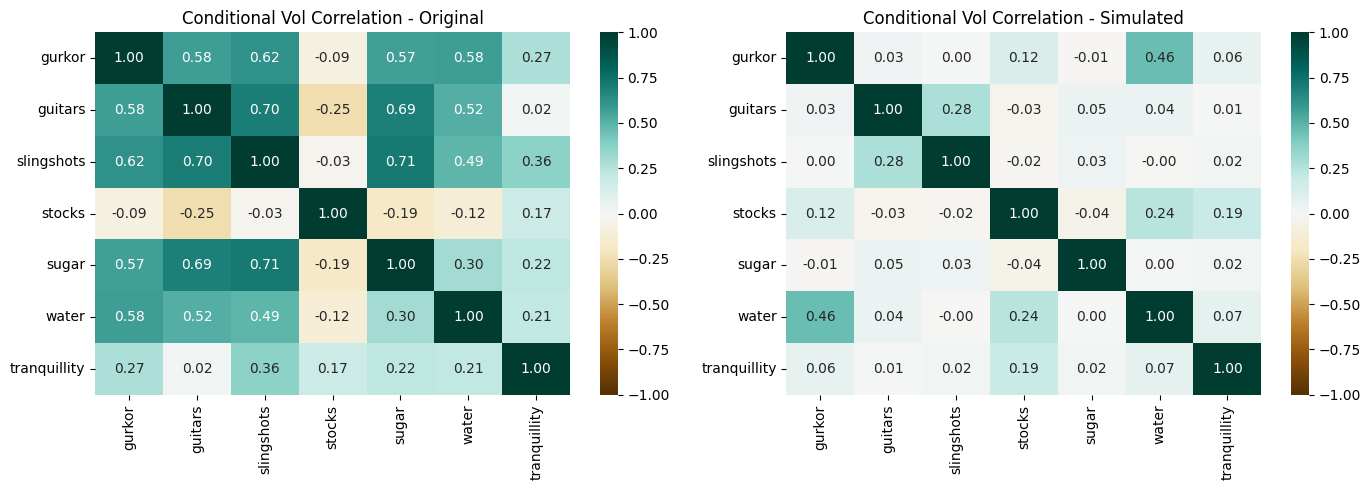

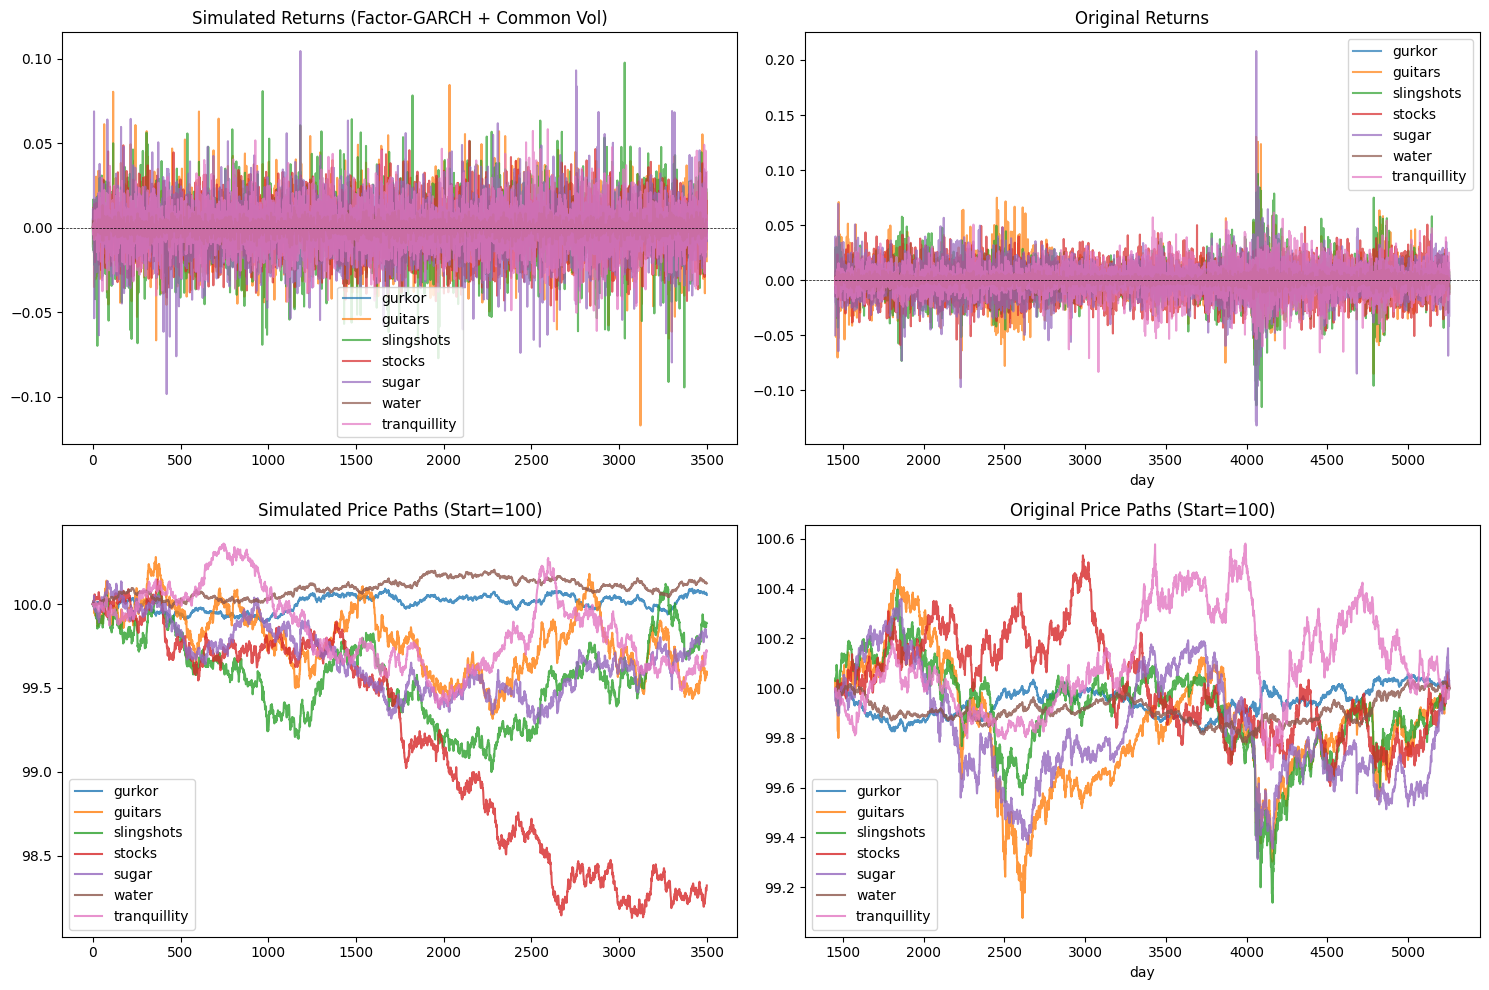

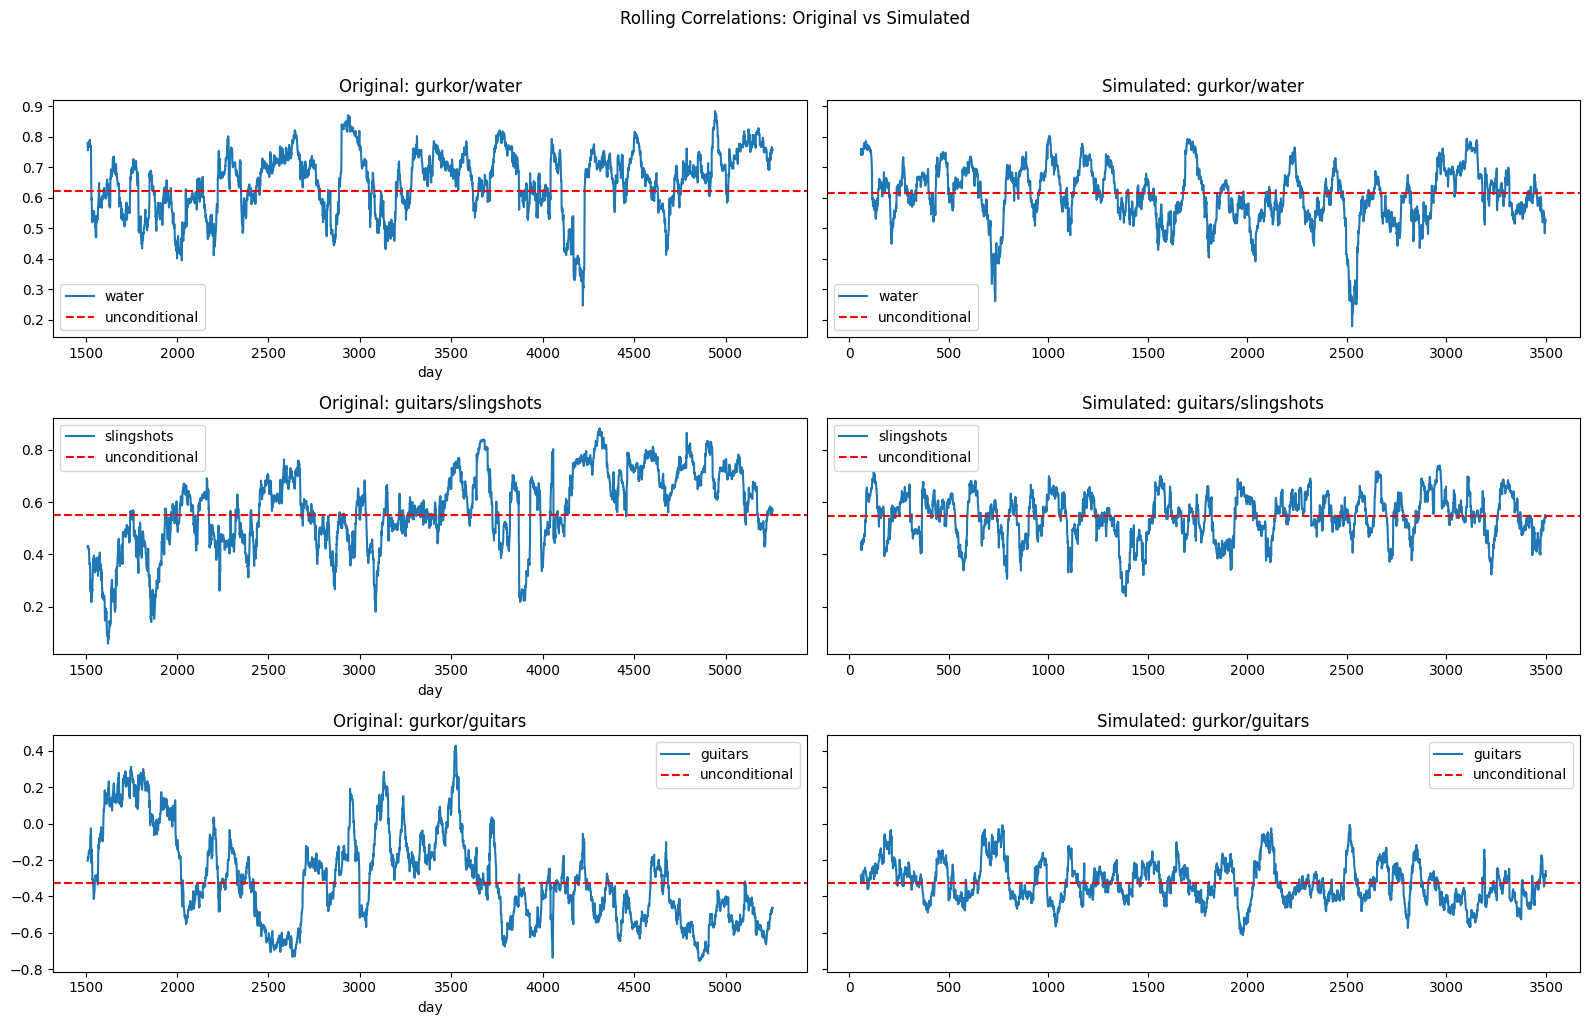

In [3]:
import numpy as np
import pandas as pd
from scipy.linalg import orthogonal_procrustes
from scipy.stats import norm, t as student_t
from sklearn.decomposition import PCA
from arch import arch_model
from hmmlearn import hmm
from statsmodels.tsa.ar_model import AutoReg
import matplotlib.pyplot as plt
import seaborn as sns

THEME = 'BrBG'
var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

# =============================================================
# DATA LOADING
# =============================================================
df_og = pd.read_csv('../data/spiff_data-2.csv')
df_og = df_og.replace(1000, np.nan).iloc[1450:]
df_original = df_og.drop(columns=['Unnamed: 0']).set_index('day')
df_og_returns = (df_original / df_original.shift(1) - 1).dropna()
df_og_returns = df_og_returns - df_og_returns.mean()
original_stds = df_og_returns.std()

# =============================================================
# LAMBDA (corrected via eigendecomposition)
# =============================================================
from numpy.linalg import eigh
og_corr = df_og_returns.corr().values
eigenvalues, eigenvectors = eigh(og_corr)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues, eigenvectors = eigenvalues[idx], eigenvectors[:, idx]
Lambda_corrected = eigenvectors * np.sqrt(eigenvalues)

# =============================================================
# VAR(2) COEFFICIENTS
# =============================================================
Phi1 = np.array([
    [ 0.066837, -0.047029, -0.032074, -0.129388, -0.120289, -0.162173,  0.029557],
    [ 0.123793, -0.006606,  0.033206, -0.265276, -0.075745,  0.035917, -0.058590],
    [ 0.026951,  0.015659,  0.000864, -0.045200, -0.024831,  0.035934, -0.043809],
    [ 0.199106,  0.007784,  0.014711, -0.220926, -0.061257, -0.002547,  0.039002],
    [-0.032751, -0.034423,  0.000487,  0.013779, -0.016192, -0.075896, -0.035988],
    [ 0.016032, -0.018288, -0.006550, -0.033598, -0.052375, -0.296606, -0.023336],
    [-0.014400, -0.001650,  0.021113, -0.040414,  0.006551,  0.035195, -0.182736]
])
Phi2 = np.array([
    [ 0.018276, -0.036829,  0.023368, -0.076605,  0.003404, -0.084637, -0.044700],
    [ 0.040158, -0.042788,  0.016656, -0.044778,  0.012176,  0.000934, -0.006445],
    [ 0.010401, -0.001657, -0.015511, -0.017275, -0.028722, -0.011827,  0.032037],
    [ 0.019280, -0.000785, -0.004241, -0.047150,  0.031045,  0.018171, -0.054329],
    [ 0.005180,  0.028481,  0.002092,  0.008334, -0.009077,  0.014023, -0.009718],
    [ 0.011509, -0.018017, -0.012928,  0.000614,  0.004906, -0.070937,  0.004123],
    [-0.004617,  0.034619,  0.008011, -0.010612, -0.000637,  0.029500, -0.061284]
])

# =============================================================
# GARCH PARAMETERS (fitted on original observed returns)
# =============================================================
garch_params_obs = {
    'gurkor':       {'omega': 0.0600, 'alpha': 0.0354, 'beta': 0.9610},
    'guitars':      {'omega': 2.3800, 'alpha': 0.0825, 'beta': 0.9076},
    'slingshots':   {'omega': 5.1221, 'alpha': 0.0866, 'beta': 0.8897},
    'stocks':       {'omega': 4.7448, 'alpha': 0.0000, 'beta': 0.9787},
    'sugar':        {'omega': 3.9366, 'alpha': 0.0844, 'beta': 0.9000},
    'water':        {'omega': 0.0581, 'alpha': 0.0320, 'beta': 0.9632},
    'tranquillity': {'omega': 1.0458, 'alpha': 0.0403, 'beta': 0.9545},
}

# =============================================================
# T-COPULA PARAMETERS (blended nu for kurtosis matching)
# =============================================================
nu_obs    = {'gurkor': 21.72, 'guitars': 18.53, 'slingshots': 32.79,
             'stocks': 401.88, 'sugar': 17.69, 'water': 22.65, 'tranquillity': 16.41}
nu_target = {'gurkor': 5.66,  'guitars': 5.04,  'slingshots': 5.28,
             'stocks': 132.55, 'sugar': 4.45,  'water': 7.65,  'tranquillity': 6.31}
alpha_blend = {'gurkor': 0.85, 'guitars': 0.727, 'slingshots': 1.034,
               'stocks': 0.8,  'sugar': 0.973,  'water': 0.93, 'tranquillity': 0.77}

nu_blended = {col: nu_obs[col] + alpha_blend[col] * (nu_target[col] - nu_obs[col])
              for col in var_names}
t_scales   = {col: 1.0 / np.sqrt(nu_blended[col] / (nu_blended[col] - 2))
              for col in var_names}

# =============================================================
# STEP A: FIT HMM ON CROSS-SECTIONAL LOG-VOL
# =============================================================
common_vol_factor = np.log(df_og_returns.std(axis=1))
common_vol_flat   = common_vol_factor.values

model_hmm = hmm.GaussianHMM(n_components=2, covariance_type='full',
                              n_iter=1000, random_state=42)
model_hmm.fit(common_vol_flat.reshape(-1, 1))
states_original = model_hmm.predict(common_vol_flat.reshape(-1, 1))

# Force state 0 = low vol
if model_hmm.means_[0] > model_hmm.means_[1]:
    model_hmm.means_     = model_hmm.means_[::-1]
    model_hmm.transmat_  = model_hmm.transmat_[::-1, ::-1]
    states_original      = 1 - states_original

regime_means = model_hmm.means_.flatten()

# Empirical transition matrix
df_trans = pd.DataFrame({'prev': states_original[:-1], 'curr': states_original[1:]})
emp_trans_matrix = pd.crosstab(df_trans['prev'], df_trans['curr'],
                                normalize='index').values
print(f"Regime means (log-vol): {regime_means.round(4)}")
print(f"Transition matrix:\n{emp_trans_matrix.round(4)}")

# =============================================================
# STEP B: FIT AR(1) ON RESIDUALS WITHIN EACH REGIME
# =============================================================
ar_params = {}
for r in [0, 1]:
    mask      = states_original == r
    residuals = common_vol_flat[mask] - regime_means[r]
    ar_model  = AutoReg(residuals, lags=1, trend='n').fit()
    ar_params[r] = {
        'ar1':   ar_model.params[0],
        'sigma': np.sqrt(ar_model.sigma2),
        'mu':    regime_means[r]
    }
    print(f"Regime {r}: ar1={ar_params[r]['ar1']:.4f}, "
          f"mu={ar_params[r]['mu']:.4f}, sigma={ar_params[r]['sigma']:.4f}")

# =============================================================
# STEP C: FIT PCA ON LOG CONDITIONAL VARIANCES
#         to get per-asset vol loadings on the common factor
# =============================================================
cond_vols_og = pd.DataFrame(index=df_og_returns.index)
for col in var_names:
    res = arch_model(df_og_returns[col] * 1000, vol='Garch',
                     p=1, q=1).fit(disp='off')
    cond_vols_og[col] = res.conditional_volatility

log_vols_og  = np.log(cond_vols_og**2)
pca_vol      = PCA(n_components=1)
pca_vol.fit(log_vols_og)
vol_loadings_vec = pca_vol.components_[0]  # shape (7,)

print(f"\nCommon vol PCA explained variance: "
      f"{pca_vol.explained_variance_ratio_[0]:.3f}")
print("Per-asset vol loadings:")
for col, ld in zip(var_names, vol_loadings_vec):
    print(f"  {col}: {ld:.4f}")

# =============================================================
# SIMULATION
# =============================================================
np.random.seed(69)
T_total = 4000
burn    = 500
T_sim   = T_total - burn

# --- 1. Simulate common vol factor (Markov + AR(1)) ---
pi0 = emp_trans_matrix[1, 0] / (emp_trans_matrix[0, 1] + emp_trans_matrix[1, 0])
pi1 = 1.0 - pi0

v_sim    = np.zeros(T_total)
v_regime = np.zeros(T_total, dtype=int)
v_regime[0] = np.random.choice(2, p=[pi0, pi1])
v_sim[0]    = ar_params[v_regime[0]]['mu']

for t in range(1, T_total):
    r_prev      = v_regime[t-1]
    r_curr      = np.random.choice(2, p=emp_trans_matrix[r_prev])
    v_regime[t] = r_curr
    prev_dev    = v_sim[t-1] - ar_params[r_prev]['mu']
    v_sim[t]    = (ar_params[r_curr]['mu'] +
                   ar_params[r_curr]['ar1'] * prev_dev +
                   np.random.normal(0, ar_params[r_curr]['sigma']))

v_sim = v_sim[burn:]  # (T_sim,)

print(f"\nCommon vol sim: mean={v_sim.mean():.3f} (target≈{common_vol_flat.mean():.3f}), "
      f"std={v_sim.std():.3f} (target≈{common_vol_flat.std():.3f})")

# --- 2. VAR(2) factor simulation (plain Gaussian) ---
F_sim = np.zeros((T_total, 7))
for t in range(2, T_total):
    F_sim[t] = Phi1 @ F_sim[t-1] + Phi2 @ F_sim[t-2] + np.random.randn(7)
F_sim = F_sim[burn:]

# --- 3. Map to observed space ---
Y_sim     = F_sim @ Lambda_corrected.T
Y_sim_std = Y_sim / Y_sim.std(axis=0)
Z         = Y_sim_std  # correlated unit-normal draws for copula

# --- 4. GARCH + common vol scaling + t-copula ---
Y_final = np.zeros_like(Y_sim)
h_obs   = np.ones((T_sim, 7))

for t in range(1, T_sim):
    # Update per-asset GARCH variance
    for i, col in enumerate(var_names):
        p = garch_params_obs[col]
        h_obs[t, i] = (p['omega'] +
                       p['alpha'] * Y_final[t-1, i]**2 +
                       p['beta'] * h_obs[t-1, i])

    # Common vol factor multiplier — asset-specific via PCA loadings
    # exp(loading_i * v_sim_t) inflates variance for assets with high loading
    common_scaling = np.exp(vol_loadings_vec * v_sim[t])
    h_combined     = h_obs[t] * common_scaling

    # Gaussian copula with t-margins for correct kurtosis
    uniform      = norm.cdf(Z[t])
    correlated_t = np.array([
        student_t.ppf(uniform[i], df=nu_blended[col]) * t_scales[col]
        for i, col in enumerate(var_names)
    ])

    Y_final[t] = correlated_t * np.sqrt(h_combined)

# Rescale to original volatility
df_returns_final = pd.DataFrame(Y_final, columns=var_names)
df_returns_final = df_returns_final.multiply(
    original_stds / df_returns_final.std(), axis=1)

# =============================================================
# VALIDATION
# =============================================================
print("\n" + "="*60)
print("FULL VALIDATION")
print("="*60)

print("\n1. VOLATILITY:")
print(pd.DataFrame({
    'Original':  original_stds,
    'Simulated': df_returns_final.std(),
    'Ratio':     (df_returns_final.std() / original_stds).round(3)
}).round(4))

print("\n2. CORRELATION (max abs error):",
      (df_og_returns.corr() - df_returns_final.corr()).abs().values.max().round(4))
print("\nOriginal:")
print(df_og_returns.corr().round(3))
print("\nSimulated:")
print(df_returns_final.corr().round(3))

print("\n3. KURTOSIS:")
print(pd.DataFrame({
    'Original':  df_og_returns.kurt(),
    'Simulated': df_returns_final.kurt()
}).round(2))

print("\n4. SKEWNESS:")
print(pd.DataFrame({
    'Original':  df_og_returns.skew(),
    'Simulated': df_returns_final.skew()
}).round(3))

print("\n5. GARCH PERSISTENCE:")
for col in var_names:
    res   = arch_model(df_returns_final[col] * 1000,
                       vol='Garch', p=1, q=1).fit(disp='off')
    p_sim = res.params['alpha[1]'] + res.params['beta[1]']
    p_og  = garch_params_obs[col]['alpha'] + garch_params_obs[col]['beta']
    print(f"  {col}: simulated={p_sim:.4f}, original={p_og:.4f}")

# Conditional vol correlations
cond_vols_final = pd.DataFrame()
for col in var_names:
    res = arch_model(df_returns_final[col] * 1000,
                     vol='Garch', p=1, q=1).fit(disp='off')
    cond_vols_final[col] = res.conditional_volatility

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cond_vols_og.corr(), annot=True, cmap=THEME,
            center=0, fmt='.2f', ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Conditional Vol Correlation - Original')
sns.heatmap(cond_vols_final.corr(), annot=True, cmap=THEME,
            center=0, fmt='.2f', ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Conditional Vol Correlation - Simulated')
plt.tight_layout()
plt.show()

# Price paths
start_value      = 100
df_prices_sim    = start_value + df_returns_final.cumsum()
df_prices_original = start_value + df_og_returns.cumsum()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
df_returns_final.plot(ax=axes[0,0], alpha=0.7,
                      title='Simulated Returns (Factor-GARCH + Common Vol)')
axes[0,0].axhline(0, color='black', linestyle='--', linewidth=0.5)
df_og_returns.plot(ax=axes[0,1], alpha=0.7, title='Original Returns')
axes[0,1].axhline(0, color='black', linestyle='--', linewidth=0.5)
df_prices_sim.plot(ax=axes[1,0], alpha=0.8,
                   title='Simulated Price Paths (Start=100)')
df_prices_original.plot(ax=axes[1,1], alpha=0.8,
                        title='Original Price Paths (Start=100)')
plt.tight_layout()
plt.show()

# Rolling correlations
window = 60
pairs  = [('gurkor', 'water'), ('guitars', 'slingshots'), ('gurkor', 'guitars')]
fig, axes = plt.subplots(len(pairs), 2, figsize=(16, 10), sharey='row')
for i, (a, b) in enumerate(pairs):
    df_og_returns[[a,b]].rolling(window).corr().unstack()[a][b].plot(
        ax=axes[i,0], title=f'Original: {a}/{b}')
    axes[i,0].axhline(df_og_returns[[a,b]].corr().iloc[0,1],
                      color='red', linestyle='--', label='unconditional')
    axes[i,0].legend()
    df_returns_final[[a,b]].rolling(window).corr().unstack()[a][b].plot(
        ax=axes[i,1], title=f'Simulated: {a}/{b}')
    axes[i,1].axhline(df_returns_final[[a,b]].corr().iloc[0,1],
                      color='red', linestyle='--', label='unconditional')
    axes[i,1].legend()
plt.suptitle('Rolling Correlations: Original vs Simulated', y=1.02)
plt.tight_layout()
plt.show()

In [2]:
print("=" * 60)
print("FINAL MODEL VALIDATION")
print("=" * 60)

print("CONDITIONAL VOL CORRELATION:")

# Recompute conditional vols for original data
cond_vols_og = pd.DataFrame()
for col in var_names:
    res = arch_model(df_og_returns[col] * 1000,
                     vol='Garch', p=1, q=1).fit(disp='off')
    cond_vols_og[col] = res.conditional_volatility

# Recompute conditional vols for simulated data
cond_vols_final = pd.DataFrame()
for col in var_names:
    res = arch_model(df_returns_final[col] * 1000,
                     vol='Garch', p=1, q=1).fit(disp='off')
    cond_vols_final[col] = res.conditional_volatility

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cond_vols_og.corr(), annot=True, cmap=THEME,
            center=0, fmt=".2f", ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Conditional Vol Correlation - Original')
sns.heatmap(cond_vols_final.corr(), annot=True, cmap=THEME,
            center=0, fmt=".2f", ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Conditional Vol Correlation - Simulated')
plt.tight_layout()
plt.show()

print("\n1. VOLATILITY (ratio should be 1.0):")
print(pd.DataFrame({
    'Original': original_stds,
    'Simulated': df_returns_final.std(),
    'Ratio': (df_returns_final.std() / original_stds).round(3)
}).round(4))

print("\n2. CORRELATION MATRIX:")
print("Original:")
print(df_og_returns.corr().round(3))
print("\nSimulated:")
print(df_returns_final.corr().round(3))
print("\nMax absolute error:")
print((df_og_returns.corr() - df_returns_final.corr()).abs().values.max().round(4))

print("\n3. KURTOSIS:")
print(pd.DataFrame({
    'Original': df_og_returns.kurt(),
    'Simulated': df_returns_final.kurt()
}).round(2))

print("\n4. SKEWNESS:")
print(pd.DataFrame({
    'Original': df_og_returns.skew(),
    'Simulated': df_returns_final.skew()
}).round(3))

print("\n5. GARCH PERSISTENCE:")
print(pd.DataFrame({
    'Original': {col: garch_params_obs[col]['persistence'] 
                 for col in var_names},
    'Simulated': {col: arch_model(df_returns_final[col] * 1000,
                  vol='Garch', p=1, q=1).fit(disp='off')
                  .params[['alpha[1]','beta[1]']].sum()
                  for col in var_names}
}).round(4))


FINAL MODEL VALIDATION
CONDITIONAL VOL CORRELATION:


NameError: name 'df_returns_final' is not defined

In [ ]:
# The idea: volatility is driven by a common market variance process
# plus asset-specific idiosyncratic variance
# h_it = lambda_i * h_market_t + omega_i

# Step 1: extract a common volatility factor from the original conditional vols
from sklearn.decomposition import PCA

# Fit PCA on log conditional variances (more stable than levels)
log_vols_og = np.log(cond_vols_og**2)
pca_vol = PCA(n_components=1)
common_vol_factor = pca_vol.fit_transform(log_vols_og)  # (T x 1)
vol_loadings = pca_vol.components_  # (1 x 7)

print("Variance explained by common vol factor:", 
      pca_vol.explained_variance_ratio_[0].round(3))
print("Vol loadings per asset:")
for col, loading in zip(var_names, vol_loadings[0]):
    print(f"  {col}: {loading:.3f}")

In [5]:
from scipy.stats import t as student_t

print("Nu estimates from GARCH standardized residuals of OBSERVED returns:")
nu_obs = {}
for col in var_names:
    res = arch_model(df_og_returns[col] * 1000, 
                     vol='Garch', p=1, q=1).fit(disp='off')
    nu, _, _ = student_t.fit(res.std_resid, floc=0, fscale=1)
    nu_obs[col] = nu
    print(f"  {col}: nu={nu:.2f}, "
          f"skew={res.std_resid.skew():.2f}, "
          f"kurt={res.std_resid.kurt():.2f}")

Nu estimates from GARCH standardized residuals of OBSERVED returns:
  gurkor: nu=21.72, skew=-0.15, kurt=1.07
  guitars: nu=18.53, skew=-0.31, kurt=1.45
  slingshots: nu=32.79, skew=-0.23, kurt=0.71
  stocks: nu=401.88, skew=-0.09, kurt=0.04
  sugar: nu=17.69, skew=-0.37, kurt=1.84
  water: nu=22.65, skew=-0.18, kurt=0.92
  tranquillity: nu=16.41, skew=-0.16, kurt=2.29


In [9]:
# Check what nu actually reproduces the observed residual kurtosis
# For t-distribution: excess kurtosis = 6/(nu-4) for nu > 4
print("Nu needed to match residual kurtosis:")
for col in var_names:
    k = df_og_returns[col].kurt()  # use full kurtosis, not just residual
    if k > 0:
        nu_needed = 6/k + 4
        print(f"  {col}: kurtosis={k:.2f}, nu_needed={nu_needed:.2f}, "
              f"current_nu={nu_obs[col]:.2f}")
        
# Diagnostic: what kurtosis does each layer contribute?
# Layer 1: raw t-shock kurtosis = 6/(nu-4)
# Layer 2: GARCH multiplies kurtosis by roughly (1 + 6*alpha^2/(1-(alpha+beta)^2-2*alpha^2))
# Layer 3: Lambda mixing dilutes kurtosis across assets

print("\nKurtosis budget per asset:")
for col in var_names:
    nu = nu_obs[col]
    t_kurt = 6/(nu-4) if nu > 4 else float('inf')
    
    a = garch_params_obs[col]['alpha']
    b = garch_params_obs[col]['beta']
    denom = 1 - (a+b)**2 - 2*a**2
    garch_mult = (1 + 6*a**2/denom) if denom > 0 else float('inf')
    
    print(f"  {col}: t_kurt={t_kurt:.2f}, "
          f"garch_multiplier={garch_mult:.2f}, "
          f"combined≈{t_kurt*garch_mult:.2f}, "
          f"target={df_og_returns[col].kurt():.2f}")

Nu needed to match residual kurtosis:
  gurkor: kurtosis=3.62, nu_needed=5.66, current_nu=21.72
  guitars: kurtosis=5.75, nu_needed=5.04, current_nu=18.53
  slingshots: kurtosis=4.70, nu_needed=5.28, current_nu=32.79
  stocks: kurtosis=0.05, nu_needed=132.55, current_nu=401.88
  sugar: kurtosis=13.47, nu_needed=4.45, current_nu=17.69
  water: kurtosis=1.64, nu_needed=7.65, current_nu=22.65
  tranquillity: kurtosis=2.59, nu_needed=6.31, current_nu=16.41

Kurtosis budget per asset:
  gurkor: t_kurt=0.34, garch_multiplier=2.61, combined≈0.88, target=3.62
  guitars: t_kurt=0.41, garch_multiplier=7.71, combined≈3.18, target=5.75
  slingshots: t_kurt=0.21, garch_multiplier=2.41, combined≈0.50, target=4.70
  stocks: t_kurt=0.02, garch_multiplier=1.00, combined≈0.02, target=0.05
  sugar: t_kurt=0.44, garch_multiplier=3.56, combined≈1.56, target=13.47
  water: t_kurt=0.32, garch_multiplier=1.82, combined≈0.58, target=1.64
  tranquillity: t_kurt=0.48, garch_multiplier=2.37, combined≈1.14, target

In [27]:
# The idea: volatility is driven by a common market variance process
# plus asset-specific idiosyncratic variance
# h_it = lambda_i * h_market_t + omega_i

# Step 1: extract a common volatility factor from the original conditional vols
from sklearn.decomposition import PCA

# Fit PCA on log conditional variances (more stable than levels)
log_vols_og = np.log(cond_vols_og**2)
pca_vol = PCA(n_components=1)
common_vol_factor = pca_vol.fit_transform(log_vols_og)  # (T x 1)
vol_loadings = pca_vol.components_  # (1 x 7)

print("Variance explained by common vol factor:", 
      pca_vol.explained_variance_ratio_[0].round(3))
print("Vol loadings per asset:")
for col, loading in zip(var_names, vol_loadings[0]):
    print(f"  {col}: {loading:.3f}")

Variance explained by common vol factor: 0.594
Vol loadings per asset:
  gurkor: 0.362
  guitars: 0.623
  slingshots: 0.469
  stocks: -0.008
  sugar: 0.428
  water: 0.271
  tranquillity: 0.065


In [28]:
# Step 2: fit GARCH on the common vol factor
common_vol_series = pd.Series(common_vol_factor.flatten())
model_common = arch_model(common_vol_series, vol='Garch', p=1, q=1)
res_common = model_common.fit(disp='off')

garch_common = {
    'omega': res_common.params['omega'],
    'alpha': res_common.params['alpha[1]'],
    'beta': res_common.params['beta[1]'],
}
print(f"\nCommon vol GARCH: alpha={garch_common['alpha']:.4f}, "
      f"beta={garch_common['beta']:.4f}, "
      f"persistence={garch_common['alpha']+garch_common['beta']:.4f}")


Common vol GARCH: alpha=0.9717, beta=0.0000, persistence=0.9717


Common vol factor stats:
  mean: -0.000
  std:  1.169
  min:  -2.279
  max:  5.327


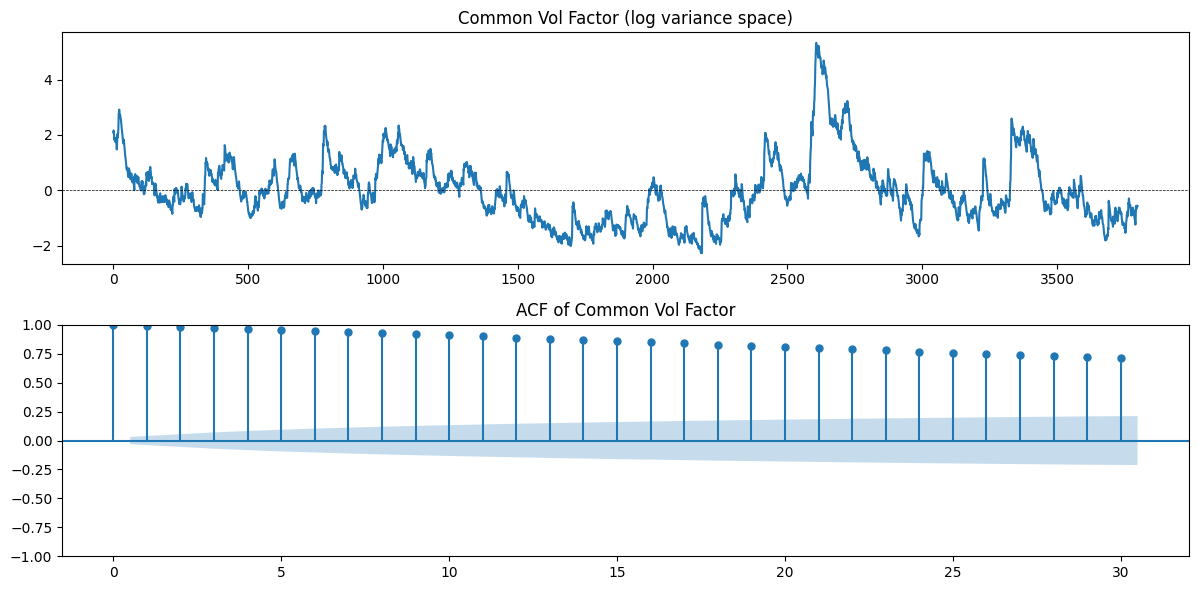


Rescaled common vol GARCH:
  alpha=0.9717
  beta=0.0000
  persistence=0.9717


In [29]:
print("Common vol factor stats:")
print(f"  mean: {common_vol_factor.mean():.3f}")
print(f"  std:  {common_vol_factor.std():.3f}")
print(f"  min:  {common_vol_factor.min():.3f}")
print(f"  max:  {common_vol_factor.max():.3f}")

# Plot it to see if it looks like a reasonable volatility process
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
pd.Series(common_vol_factor.flatten()).plot(ax=axes[0], 
                                             title='Common Vol Factor (log variance space)')
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.5)

# Also check autocorrelation — should be high for a vol process
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(common_vol_factor.flatten(), lags=30, ax=axes[1], 
         title='ACF of Common Vol Factor')
plt.tight_layout()
plt.show()

# And refit with rescaling
common_scaled = (common_vol_factor.flatten() - common_vol_factor.mean()) 
common_scaled = common_scaled / common_scaled.std() * 100  # rescale to arch range

model_common = arch_model(pd.Series(common_scaled), 
                          vol='Garch', p=1, q=1, dist='normal')
res_common = model_common.fit(disp='off')
print(f"\nRescaled common vol GARCH:")
print(f"  alpha={res_common.params['alpha[1]']:.4f}")
print(f"  beta={res_common.params['beta[1]']:.4f}")
print(f"  persistence={res_common.params['alpha[1]']+res_common.params['beta[1]']:.4f}")

might not actually be garch, maybe more of a regime switching?

Hurst exponent: 0.451
  H=0.5: random walk (no memory)
  H>0.5: long memory (persistent)
  H>0.9: near unit root / regime-like

HMM regime means: [-0.689  1.154]
HMM transition matrix:
          Low vol  High vol
Low vol     0.993     0.007
High vol    0.012     0.988


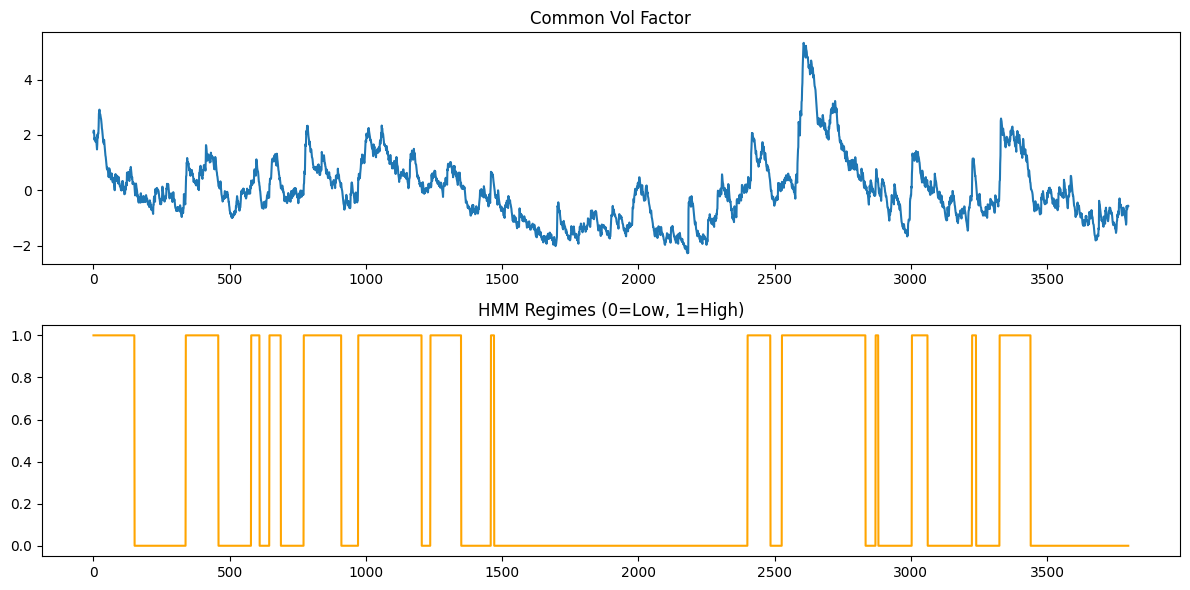

In [31]:
# Test 1: Hurst exponent — measures long memory
# H > 0.5 means long memory, H near 1 means near unit root
from numpy import cumsum, log, polyfit, sqrt, std, subtract

def hurst(ts):
    lags = range(2, 100)
    tau = [sqrt(std(subtract(ts[lag:], ts[:-lag]))) for lag in lags]
    poly = polyfit(log(lags), log(tau), 1)
    return poly[0] * 2.0

h = hurst(common_vol_factor.flatten())
print(f"Hurst exponent: {h:.3f}")
print(f"  H=0.5: random walk (no memory)")
print(f"  H>0.5: long memory (persistent)")
print(f"  H>0.9: near unit root / regime-like")

# Test 2: simple regime detection via HMM
from hmmlearn import hmm

# Fit 2-state HMM on common vol factor
model_hmm = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=100)
model_hmm.fit(common_vol_factor)
states = model_hmm.predict(common_vol_factor)

print(f"\nHMM regime means: {model_hmm.means_.flatten().round(3)}")
print(f"HMM transition matrix:")
print(pd.DataFrame(model_hmm.transmat_.round(3), 
                   index=['Low vol', 'High vol'],
                   columns=['Low vol', 'High vol']))

# Plot regimes
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
pd.Series(common_vol_factor.flatten()).plot(ax=axes[0], 
                                             title='Common Vol Factor')
pd.Series(states.astype(float)).plot(ax=axes[1], 
                                      title='HMM Regimes (0=Low, 1=High)',
                                      color='orange')
plt.tight_layout()
plt.show()

Low vol regime:  mean=-0.689, std=0.597, avg duration=151 days
High vol regime: mean=1.154, std=0.965, avg duration=85 days


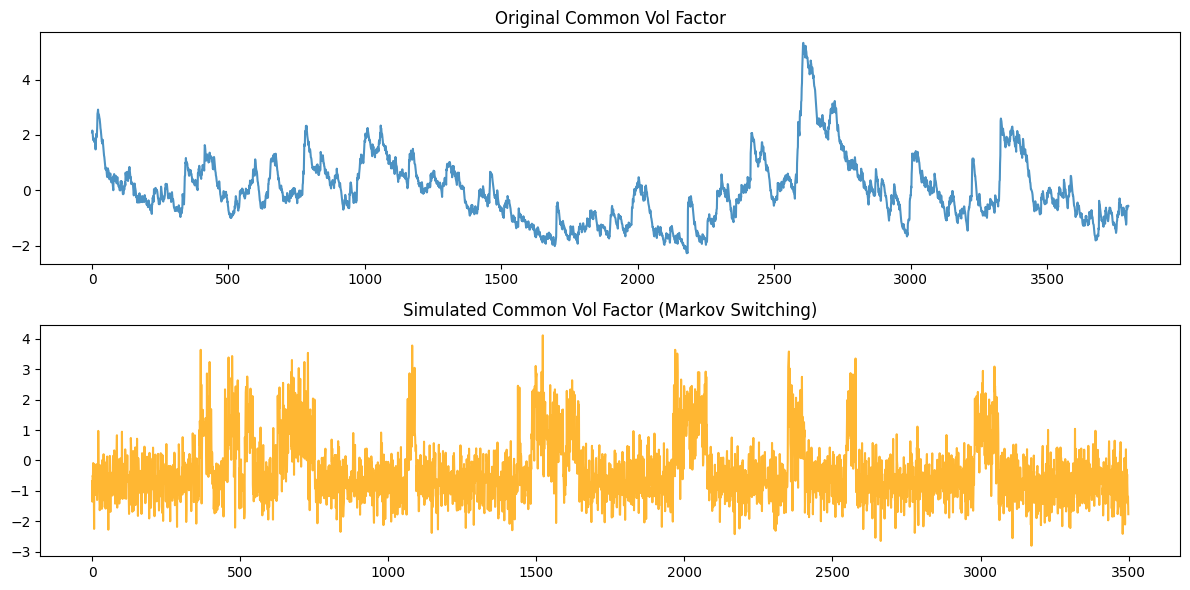

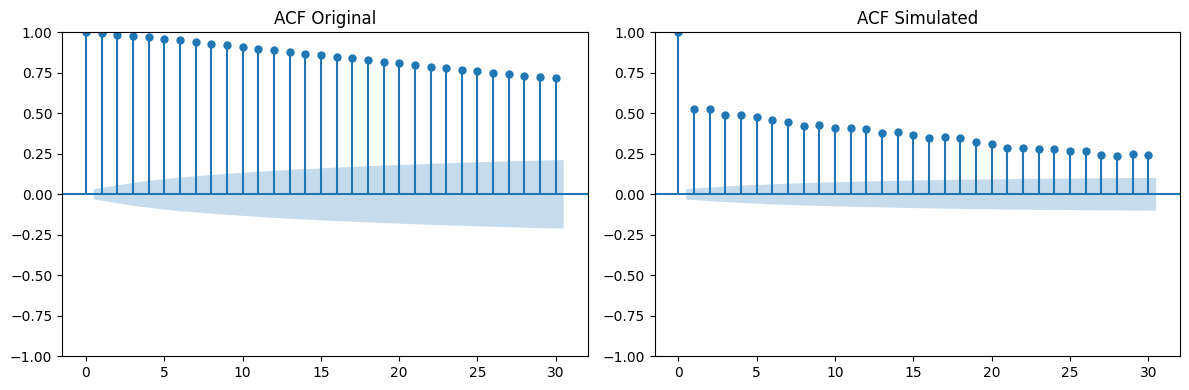

In [32]:
# Simulate common vol factor via Markov switching
transition_matrix = model_hmm.transmat_
regime_means = model_hmm.means_.flatten()
regime_stds = np.sqrt(model_hmm.covars_.flatten())

print(f"Low vol regime:  mean={regime_means[0]:.3f}, std={regime_stds[0]:.3f}, "
      f"avg duration={1/(1-transition_matrix[0,0]):.0f} days")
print(f"High vol regime: mean={regime_means[1]:.3f}, std={regime_stds[1]:.3f}, "
      f"avg duration={1/(1-transition_matrix[1,1]):.0f} days")

# Simulate
np.random.seed(42)
T_sim = len(Y_sim)
common_vol_sim = np.zeros(T_sim)
regime_sim = np.zeros(T_sim, dtype=int)

# Start in low vol regime
regime_sim[0] = 0
common_vol_sim[0] = regime_means[0]

for t in range(1, T_sim):
    # Transition
    regime_sim[t] = np.random.choice(2, p=transition_matrix[regime_sim[t-1]])
    # Draw from regime distribution
    common_vol_sim[t] = np.random.normal(
        regime_means[regime_sim[t]], 
        regime_stds[regime_sim[t]]
    )

# Plot to verify it looks like the original
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
pd.Series(common_vol_factor.flatten()).plot(
    ax=axes[0], title='Original Common Vol Factor', alpha=0.8)
pd.Series(common_vol_sim).plot(
    ax=axes[1], title='Simulated Common Vol Factor (Markov Switching)', 
    color='orange', alpha=0.8)
plt.tight_layout()
plt.show()

# Check ACF matches
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(common_vol_factor.flatten(), lags=30, ax=axes[0], 
         title='ACF Original')
plot_acf(common_vol_sim, lags=30, ax=axes[1], 
         title='ACF Simulated')
plt.tight_layout()
plt.show()

too noisy, add AR(1) as well

Regime 0: const=-0.015, ar1=0.979, sigma=0.122
Regime 1: const=0.012, ar1=0.988, sigma=0.146


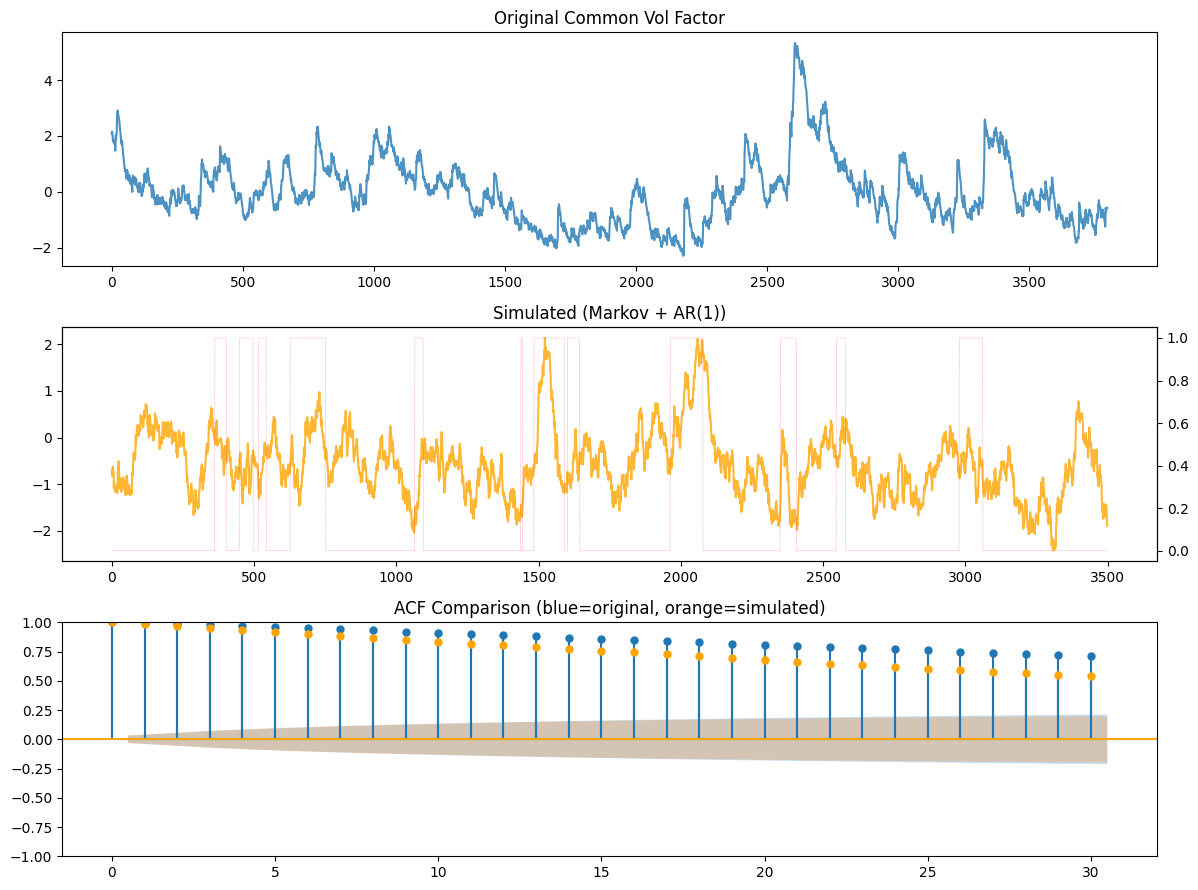


Original: mean=-0.000, std=1.169
Simulated: mean=-0.568, std=0.710


In [33]:
# Fit AR(1) within each regime separately
from statsmodels.tsa.ar_model import AutoReg

common_vol_flat = common_vol_factor.flatten()
states_original = model_hmm.predict(common_vol_factor)

ar_params = {}
for regime in [0, 1]:
    mask = states_original == regime
    regime_data = common_vol_flat[mask]
    
    # Fit AR(1) on within-regime values
    ar_model = AutoReg(regime_data, lags=1).fit()
    ar_params[regime] = {
        'const': ar_model.params[0],
        'ar1': ar_model.params[1],
        'sigma': np.sqrt(ar_model.sigma2),
        'mean': regime_means[regime],
        'std': regime_stds[regime]
    }
    print(f"Regime {regime}: const={ar_model.params[0]:.3f}, "
          f"ar1={ar_model.params[1]:.3f}, "
          f"sigma={np.sqrt(ar_model.sigma2):.3f}")

# Simulate with AR(1) within each regime
np.random.seed(42)
common_vol_sim = np.zeros(T_sim)
regime_sim = np.zeros(T_sim, dtype=int)

regime_sim[0] = 0
common_vol_sim[0] = regime_means[0]

for t in range(1, T_sim):
    # Markov transition
    regime_sim[t] = np.random.choice(2, p=transition_matrix[regime_sim[t-1]])
    p = ar_params[regime_sim[t]]
    
    # AR(1) update within regime
    common_vol_sim[t] = (p['const'] + 
                         p['ar1'] * common_vol_sim[t-1] +  # carry forward momentum
                         np.random.normal(0, p['sigma']))

# Plot comparison
fig, axes = plt.subplots(3, 1, figsize=(12, 9))
pd.Series(common_vol_flat).plot(
    ax=axes[0], title='Original Common Vol Factor', alpha=0.8)

pd.Series(common_vol_sim).plot(
    ax=axes[1], title='Simulated (Markov + AR(1))', color='orange', alpha=0.8)

# Overlay regimes
ax2 = axes[1].twinx()
pd.Series(regime_sim.astype(float)).plot(
    ax=ax2, color='red', alpha=0.2, linewidth=0.5)

# ACF comparison
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(common_vol_flat, lags=30, ax=axes[2], alpha=0.05)
plot_acf(common_vol_sim, lags=30, ax=axes[2], alpha=0.05, color='orange')
axes[2].set_title('ACF Comparison (blue=original, orange=simulated)')
plt.tight_layout()
plt.show()

print(f"\nOriginal: mean={common_vol_flat.mean():.3f}, std={common_vol_flat.std():.3f}")
print(f"Simulated: mean={common_vol_sim.mean():.3f}, std={common_vol_sim.std():.3f}")

In [ ]:
Nästa steg: skew!

SyntaxError: invalid syntax (2776075913.py, line 1)